In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader
from torch.utils.data import Dataset
from torch_geometric.nn import GCNConv, global_mean_pool
from GCN_helpers import *

## Load Data
From `TRAIN_NEW` and `TEST` folder, we will load:
- Functional MRI connectome data
- Targets: ADHD diagnosis & Sex (only from `TRAIN_NEW`)

In [14]:
# === Load data ===
data_path = "/Users/Haley/Desktop/WiDs Datathon/widsdatathon2025/"
connectome_train = pd.read_csv(f"{data_path}TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")
targets_train = pd.read_excel(f"{data_path}TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")
connectome_test = pd.read_csv(f"{data_path}TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")

# Check shapes
print("Train Connectome:", connectome_train.shape)
print("Train Targets:", targets_train.shape) 
print("Test Connectome:", connectome_test.shape)

KeyboardInterrupt: 

In [7]:
# Example for the first participant
flattened_fcm = connectome_train.iloc[0, 1:].values  # Skip the participant_id column
fcm_matrix = flatten_to_square_matrix(flattened_fcm)
print(fcm_matrix.shape)  # Should print (200, 200)

(200, 200)


In [9]:
connectivity_matrices = unflatten_matrices(connectome_train)
print("Train Connectomes:",connectivity_matrices.shape)  # Should print (N, 200, 200), where N is the number of participants
connectivity_matrices_test = unflatten_matrices(connectome_test)
print("Test Connectomes:",connectivity_matrices_test.shape) 

Train Connectomes: (1213, 200, 200)
Test Connectomes: (304, 200, 200)


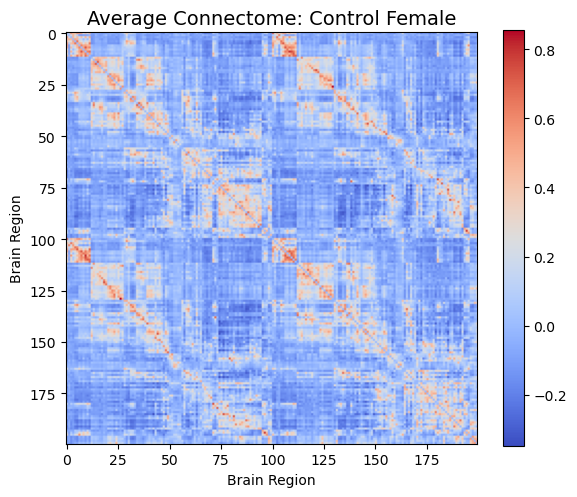

In [7]:
plot_average_connectome(connectivity_matrices, targets_train, adhd=0, sex=1)

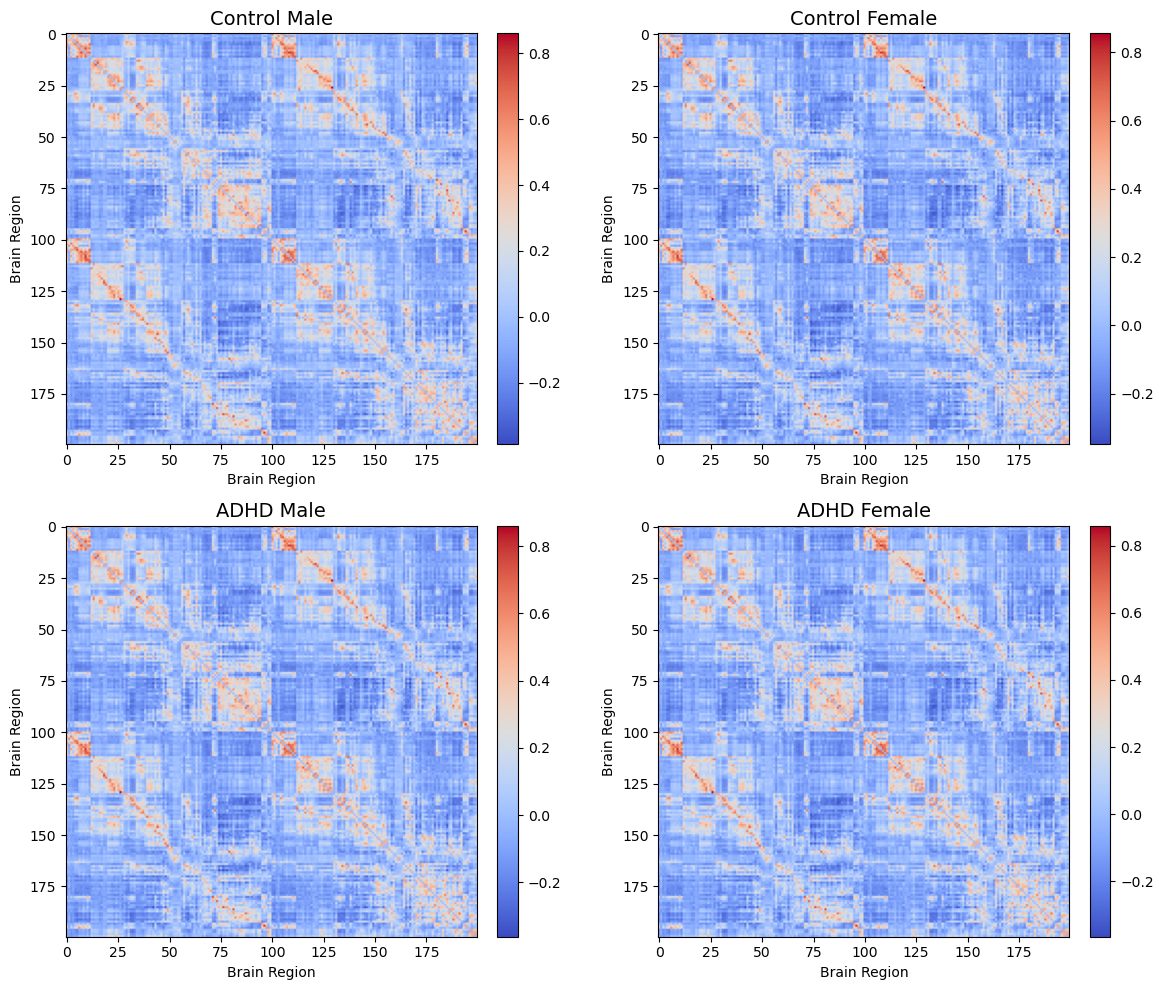

In [10]:
plot_grouped_connectomes(connectivity_matrices, targets_train)

In [12]:
train_data = data_to_tensor(connectivity_matrices,targets_train)
test_data = data_to_tensor_test(connectivity_matrices_test)

In [12]:
# Run tester on old model
model = GCN()
model.load_state_dict(torch.load("model.pt"))
tester = Tester(model, test_data, connectome_test)
tester.evaluate()
tester.save_submission("submission_GNN.csv")
tester.get_submission_df

/opt/anaconda3/envs/wids-datathon/lib/python3.13/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Submission saved to submission_GNN.csv


<bound method Tester.get_submission_df of <GNN_helpers.Tester object at 0x31ba0e7b0>>

In [ ]:
model = GCN()
# model.load_state_dict(torch.load("model.pt"))
trainer = Trainer(model, train_data)
trainer.train(epochs=100)
trainer.plot_losses()

/opt/anaconda3/envs/wids-datathon/lib/python3.13/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 0, Loss: 0.6395
Epoch 10, Loss: 0.6358


In [15]:
newtester = Tester(trainer.model, test_data, connectome_test)
newtester.evaluate()
newtester.save_submission("new_submission_GNN.csv")
newtester.get_submission_df

Submission saved to new_submission_GNN.csv


<bound method Tester.get_submission_df of <GNN_helpers.Tester object at 0x17e342ad0>>